# The Determinant of a Product

*Course notes for **Math for Machine Learning**, C1 · W4 · L1 · V04 — "The Determinant of a Product" (DeepLearning.AI).*

Now that the determinant means **area scaling**, the determinant of a **product** of matrices follows a beautifully simple rule:

$$ \boxed{\;\det(AB) = \det(A)\,\det(B)\;} $$

We'll see why it's obvious geometrically, then use it to reason about products involving **singular** matrices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. The rule, on a concrete example

Take

$$ A = \begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}\;(\det = 5), \qquad B = \begin{pmatrix} 1 & 1 \\ -2 & 1 \end{pmatrix}\;(\det = 3). $$

Their product is $AB = \begin{pmatrix} 1 & 4 \\ -3 & 3 \end{pmatrix}$, whose determinant is $1\cdot 3 - 4\cdot(-3) = 15$. And indeed $5 \times 3 = 15$.

In [2]:
A = np.array([[3, 1],
              [1, 2]])
B = np.array([[1, 1],
              [-2, 1]])
AB = A @ B
print('AB =\n', AB)
print()
print('det(A)        =', np.linalg.det(A))
print('det(B)        =', np.linalg.det(B))
print('det(A)*det(B) =', np.linalg.det(A) * np.linalg.det(B))
print('det(AB)       =', np.linalg.det(AB), '  <- equal')

AB =
 [[ 1  4]
 [-3  3]]

det(A)        = 5.000000000000001
det(B)        = 2.9999999999999996
det(A)*det(B) = 15.0
det(AB)       = 15.0   <- equal


## 2. Why: determinants are area-scaling factors

A transformation with determinant $d$ **multiplies every area by $d$** — not just the unit square, *any* region. So composing two transformations:

- $A$ blows areas up by $5$,
- $B$ blows areas up by $3$,
- doing $A$ then $B$ blows areas up by $5 \times 3 = 15$.

The unit square (area $1$) ends up with area $15$, so $\det(AB) = 15$. Multiplying the scale factors **is** multiplying the determinants — no messy algebra needed.

*(Note: $AB$ means "apply $B$ first, then $A$" — but since we're multiplying scale factors, the order doesn't change the product of determinants.)*

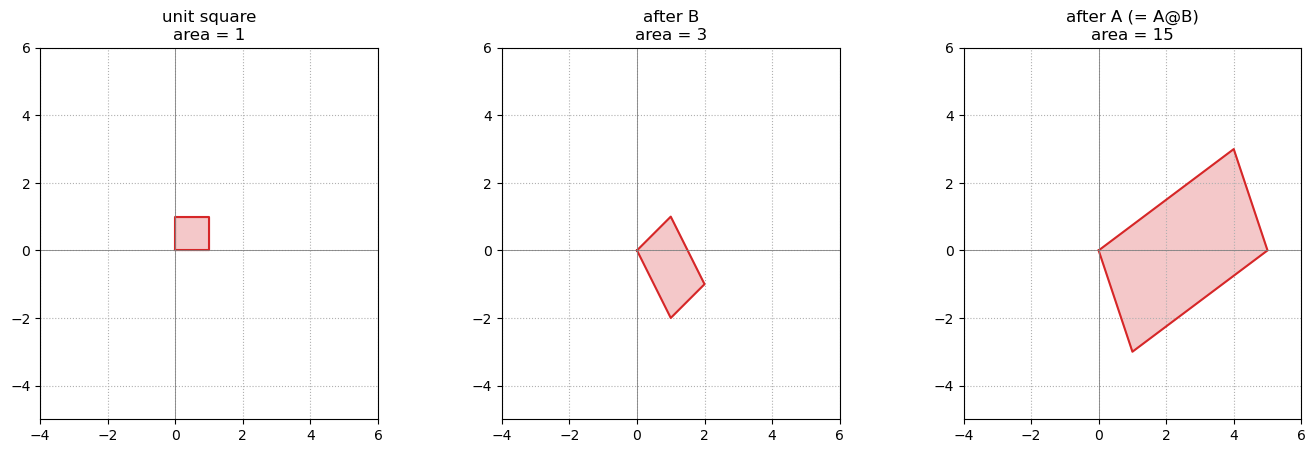

area after A@B = 15.0


In [3]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
s1 = B @ square          # apply B first (area x3)
s2 = A @ s1              # then A (area x5)  == (A@B) @ square

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, S, ttl in [(axes[0], square, 'unit square\narea = 1'),
                   (axes[1], s1, 'after B\narea = 3'),
                   (axes[2], s2, 'after A (= A@B)\narea = 15')]:
    ax.fill(S[0], S[1], color='C3', alpha=0.25); ax.plot(S[0], S[1], 'C3')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_title(ttl)
    ax.set_xlim(-4, 6); ax.set_ylim(-5, 6)
plt.tight_layout(); plt.show()

print('area after A@B =', abs(np.linalg.det(A @ B)))

## 3. Quiz: singular $\times$ non-singular

**What is the product of a singular and a non-singular matrix (in any order)?** Always **singular**. If $B$ is singular then $\det(B) = 0$, so

$$ \det(AB) = \det(A)\cdot\det(B) = \det(A)\cdot 0 = 0, $$

making $AB$ singular — no matter what $A$ is. It's the matrix version of "**anything times $0$ is $0$**". Geometrically: the singular matrix already squashes everything onto a **line** (area $0$), and the other transformation can't restore the lost dimension, so the composite still has area $0$.

In [4]:
N = np.array([[3, 1], [1, 2]])   # non-singular, det 5
Sg = np.array([[1, 1], [2, 2]])  # singular, det 0

print('det(N)     =', np.linalg.det(N))
print('det(Sg)    =', np.linalg.det(Sg))
print('det(N@Sg)  =', round(np.linalg.det(N @ Sg), 3), ' -> singular')
print('det(Sg@N)  =', round(np.linalg.det(Sg @ N), 3), ' -> singular (either order)')

det(N)     = 5.000000000000001
det(Sg)    = 0.0
det(N@Sg)  = 0.0  -> singular
det(Sg@N)  = 0.0  -> singular (either order)


## 4. A quick corollary: the determinant of an inverse

The product rule instantly explains inverses. Since $A A^{-1} = I$ and $\det(I) = 1$:

$$ \det(A)\,\det(A^{-1}) = \det(I) = 1 \quad\Longrightarrow\quad \det(A^{-1}) = \frac{1}{\det(A)}. $$

This is why a singular matrix ($\det = 0$) has no inverse — you can't divide by $0$.

In [5]:
A = np.array([[3, 1], [1, 2]])
print('det(A)      =', np.linalg.det(A))
print('det(inv A)  =', round(np.linalg.det(np.linalg.inv(A)), 4))
print('1 / det(A)  =', round(1 / np.linalg.det(A), 4), ' <- equal')

det(A)      = 5.000000000000001
det(inv A)  = 0.2
1 / det(A)  = 0.2  <- equal


## Summary

- **$\det(AB) = \det(A)\det(B)$** — the determinant of a product is the product of the determinants.
- **Why:** the determinant is an **area-scaling factor**, and composing transformations **multiplies** their scale factors. Great for analyzing a **cascade** of transformations.
- **Singular absorbs:** any matrix times a singular matrix is singular ($\det = \text{something}\times 0 = 0$), just like multiplying a number by $0$.
- **Corollary:** $\det(A^{-1}) = 1/\det(A)$, so $\det = 0$ matrices can't be inverted.